In [1]:
import os, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from _utils import MMDataset

class DUCMME(nn.Module):
    def __init__(self, embed_dim=200, num_samples=10000, num_views=3, feature_dims=[1000, 1000, 500], hidden_dims=[512, 512, 512], n_clusters=10, alpha=1.0):
        super(DUCMME, self).__init__()
        self.embed_dim = embed_dim; self.num_samples = num_samples; self.num_views = num_views; self.feature_dims = feature_dims; self.hidden_dims = hidden_dims; self.n_clusters = n_clusters; self.alpha = alpha
        # 1. Multi-view Feature Extraction by Fusion-Net
        self.fusion_net_encoder = nn.ModuleList([nn.Sequential(nn.Linear(feature_dims[i], hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                               nn.Linear(hidden_dims[i], embed_dim)) for i in range(num_views)]) # encode each view
        self.fusion_net_mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=10, batch_first=True) # batch_first=True: (batch_size, seq_len, hidden_dim)
        self.fusion_net_linear = nn.Linear(3*embed_dim, embed_dim) # linear projection of the fused encoded features
        # 2. Uncertainty-Aware Reconstruction by Reconstruction-Net and Uncertainty-Net
        self.reconstruct_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # reconstruct each view
        self.uncertainty_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # predict uncertainty for each view
        # 3. Deep Embedding Clustering by DEC
        self._cluster_centers = nn.Parameter(torch.Tensor(self.n_clusters, self.embed_dim))
        nn.init.xavier_uniform_(self._cluster_centers.data)
        
    def forward_embedding(self, x):
        encoded_output_list = [self.fusion_net_encoder[i](x[i]) for i in range(self.num_views)] # encode each view
        encoded_output_list = torch.stack(encoded_output_list, dim=1) # stack the encoded features from all views, (batch_size, num_views, embed_dim)
        encoded_output_list, _ = self.fusion_net_mha(encoded_output_list, encoded_output_list, encoded_output_list) # fuse the encoded features from all views by a multihead attention, (batch_size, num_views, embed_dim)
        encoded_output_list = encoded_output_list.contiguous().view(encoded_output_list.shape[0], -1) # flatten the encoded features, (batch_size, num_views*embed_dim)
        embedding = self.fusion_net_linear(encoded_output_list) # linear projection of the fused encoded features
        return embedding # get the embedding of the latent space H, (batch_size, embed_dim)

    def forward_uncertainty_aware_reconstruction(self, x):
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        reconstructions = [self.reconstruct_net_list[i](embedding) for i in range(self.num_views)] # reconstruct each view
        uncertainties = [self.uncertainty_net_list[i](embedding) for i in range(self.num_views)] # predict uncertainty for each view
        return reconstructions, uncertainties
        
    def forward_similarity_matrix_q(self, x): # calculate the similarity matrix q using t-distribution
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        q = 1.0 / (1.0 + torch.sum((embedding.unsqueeze(1) - self._cluster_centers) ** 2, dim=2) / self.alpha) # shape: [batch_size, n_clusters]
        q = q ** ((self.alpha + 1.0) / 2.0) # , shape: [batch_size, n_clusters]
        q = q / torch.sum(q, dim=1, keepdim=True) # Normalize q to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return q, embedding # q can be regarded as the probability of the sample belonging to each cluster
    
    @property
    def cluster_centers(self):
        return self._cluster_centers.data.detach().cpu().numpy() # shape: (n_clusters, embed_dim)
    
    @cluster_centers.setter
    def cluster_centers(self, centers): # shape: (n_clusters, embed_dim)
        centers = torch.tensor(centers, dtype=torch.float32, device=self._cluster_centers.device)
        self._cluster_centers.data.copy_(centers) # copy the cluster centers to the model, set the cluster centers to the new cluster centers
        
    @staticmethod
    def target_distribution(q):
        weight = q ** 2 / torch.sum(q, dim=0) # shape: [batch_size, n_clusters]
        p = weight / torch.sum(weight, dim=1, keepdim=True) # Normalize p to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return p.clone().detach()
    
    def reconstruction_loss(self, x):
        x_rec, _ = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([F.mse_loss(x_rec[v], x[v], reduction='mean') for v in range(self.num_views)]) # sum the losses from all views
    
    def uncertainty_aware_reconstruction_loss(self, x):
        x_rec, log_sigma_2 = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([0.5 * torch.mean((x_rec[v] - x[v])**2 * torch.exp(-log_sigma_2[v]) + log_sigma_2[v]) for v in range(self.num_views)]) # uncertainty is equal to log_sigma_2
    
    def clustering_loss(self, x, p):
        q, _ = self.forward_similarity_matrix_q(x) # shape: [batch_size, n_clusters]
        return F.kl_div(q.log(), p, reduction='batchmean') # shape: ()

In [2]:
random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0) # Set random seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = MMDataset('./data/data_sc_multiomics/TEA/', concat_data=False); data = [x.clone().to(device) for x in dataset.X]; label = dataset.Y.clone().numpy()
data_views = dataset.data_views; data_samples = dataset.data_samples; data_features = dataset.data_features; data_categories = dataset.categories

def predict_uncertainty_with_HDUMEC(data_add_noise):
    model = DUCMME(embed_dim=20, feature_dims=data_features, num_views=data_views, hidden_dims=[512, 512, 512], num_samples=data_samples, n_clusters=data_categories, alpha=1.0).to(device)
    print("\n=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===")
    print("Basic reconstruction training...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.reconstruction_loss(data_add_noise)
        loss.backward()
        optimizer.step()
        # print(f'Epoch {epoch} completed. Average Loss: {loss.item():.4f}')
    print("Uncertainty-aware reconstruction finetuning...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.uncertainty_aware_reconstruction_loss(data_add_noise)
        loss.backward()
        optimizer.step()
        # print(f'Epoch {epoch} completed. Average Loss: {loss.item():.4f}')
    model.eval()
    with torch.no_grad():
        reconstructions, uncertainties = model.forward_uncertainty_aware_reconstruction(data_add_noise)
    uncertainties = [np.exp(0.5 * uncertainties[i].cpu().numpy()) for i in range(data_views)]
    modality_uncertainties = [np.mean(uncertainties[i], axis=1) for i in range(data_views)]
    return modality_uncertainties

modality_rna shape: (25517, 50)
modality_protein shape: (25517, 47)
modality_atac shape: (25517, 30)


In [3]:
data_add_noise_variance_0_ratio_0 = [x.clone() for x in data] # 0% samples have 0% noise
data_add_noise_variance_0_ratio_0_uncertainties = predict_uncertainty_with_HDUMEC(data_add_noise_variance_0_ratio_0)
data_add_noise_variance_1_ratio_50 = [x.clone() for x in data] # 50% samples have 100% noise, variance = 1
for view in range(data_views):
    noise = np.random.normal(0, 1, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, 1)
    selected_samples = np.random.choice([1, 0], size=(data_samples,), p=[0.5, 0.5])
    noise = noise * selected_samples[:, np.newaxis]
    # selected_features = np.random.choice([1, 0], size=(data_features[view],), p=[0.5, 0.5])
    # noise = noise * selected_features[np.newaxis, :]
    data_add_noise_variance_1_ratio_50[view] = data_add_noise_variance_1_ratio_50[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_add_noise_variance_1_ratio_50_uncertainties = predict_uncertainty_with_HDUMEC(data_add_noise_variance_1_ratio_50)
data_add_noise_variance_1_ratio_100 = [x.clone() for x in data] # 100% samples have 100% noise, variance = 1
for view in range(data_views):
    noise = np.random.normal(0, 1, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, 1)
    selected_samples = np.random.choice([1, 0], size=(data_samples,), p=[1, 0])
    noise = noise * selected_samples[:, np.newaxis]
    data_add_noise_variance_1_ratio_100[view] = data_add_noise_variance_1_ratio_100[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_add_noise_variance_1_ratio_100_uncertainties = predict_uncertainty_with_HDUMEC(data_add_noise_variance_1_ratio_100)
data_add_noise_variance_2_ratio_100 = [x.clone() for x in data] # 100% samples have 100% noise, variance = 2
for view in range(data_views):
    noise = np.random.normal(0, 2, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, 2)
    selected_samples = np.random.choice([1, 0], size=(data_samples,), p=[1, 0])
    noise = noise * selected_samples[:, np.newaxis]
    data_add_noise_variance_2_ratio_100[view] = data_add_noise_variance_2_ratio_100[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_add_noise_variance_2_ratio_100_uncertainties = predict_uncertainty_with_HDUMEC(data_add_noise_variance_2_ratio_100)


=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===
Basic reconstruction training...
Uncertainty-aware reconstruction finetuning...

=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===
Basic reconstruction training...
Uncertainty-aware reconstruction finetuning...

=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===
Basic reconstruction training...
Uncertainty-aware reconstruction finetuning...

=== Stage 1: Uncertainty-Aware Reconstruction Pretraining ===
Basic reconstruction training...
Uncertainty-aware reconstruction finetuning...


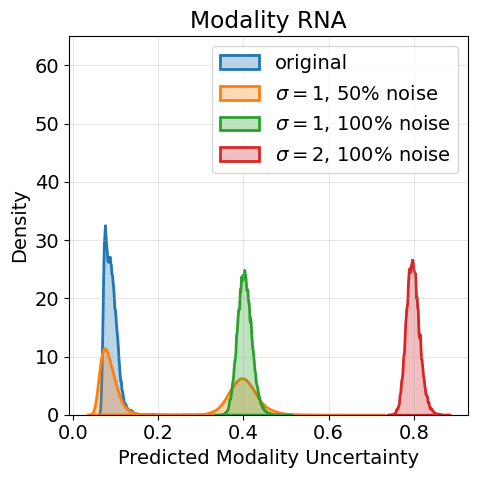

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.size'] = 14
figure_dir = './figure/hdur_modality_level/TEA/'
os.makedirs(figure_dir, exist_ok=True)

uncertainty_1 = data_add_noise_variance_0_ratio_0_uncertainties[0]
uncertainty_2 = data_add_noise_variance_1_ratio_50_uncertainties[0]
uncertainty_3 = data_add_noise_variance_1_ratio_100_uncertainties[0]
uncertainty_4 = data_add_noise_variance_2_ratio_100_uncertainties[0]
plt.figure(figsize=(5, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
sns.kdeplot(data=uncertainty_1, label='original', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[0], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_2, label=rf'$\sigma=1$, $50\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[1], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_3, label=rf'$\sigma=1$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[2], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_4, label=rf'$\sigma=2$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[3], alpha=0.3, linewidth=2)
plt.xlabel('Predicted Modality Uncertainty')
plt.ylabel('Density')
plt.ylim(0, 65)
plt.title('Modality RNA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_modality_uncertainty_RNA.png'), dpi=300)
plt.show()

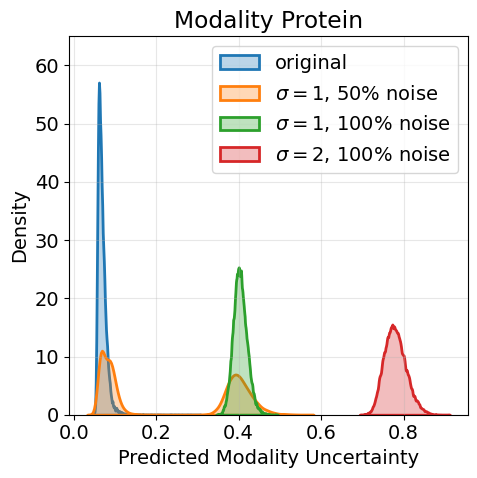

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
uncertainty_1 = data_add_noise_variance_0_ratio_0_uncertainties[1]
uncertainty_2 = data_add_noise_variance_1_ratio_50_uncertainties[1]
uncertainty_3 = data_add_noise_variance_1_ratio_100_uncertainties[1]
uncertainty_4 = data_add_noise_variance_2_ratio_100_uncertainties[1]
plt.figure(figsize=(5, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
sns.kdeplot(data=uncertainty_1, label='original', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[0], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_2, label=rf'$\sigma=1$, $50\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[1], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_3, label=rf'$\sigma=1$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[2], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_4, label=rf'$\sigma=2$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[3], alpha=0.3, linewidth=2)
plt.xlabel('Predicted Modality Uncertainty')
plt.ylabel('Density')
plt.ylim(0, 65)
plt.title('Modality Protein')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_modality_uncertainty_protein.png'), dpi=300)
plt.show()

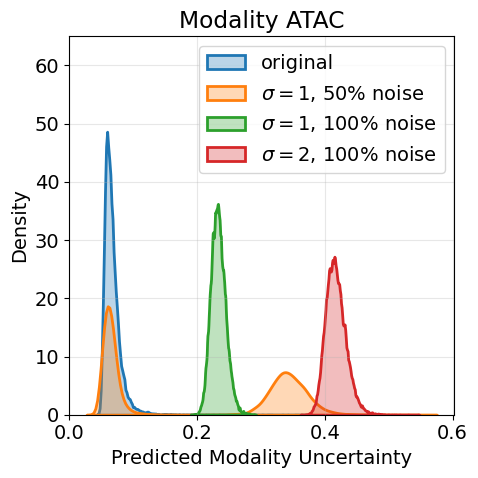

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
uncertainty_1 = data_add_noise_variance_0_ratio_0_uncertainties[2]
uncertainty_2 = data_add_noise_variance_1_ratio_50_uncertainties[2]
uncertainty_3 = data_add_noise_variance_1_ratio_100_uncertainties[2]
uncertainty_4 = data_add_noise_variance_2_ratio_100_uncertainties[2]
plt.figure(figsize=(5, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
sns.kdeplot(data=uncertainty_1, label='original', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[0], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_2, label=rf'$\sigma=1$, $50\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[1], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_3, label=rf'$\sigma=1$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[2], alpha=0.3, linewidth=2)
sns.kdeplot(data=uncertainty_4, label=rf'$\sigma=2$, $100\%$ noise', fill=True, clip=(0, 1), bw_adjust=0.3, color=colors[3], alpha=0.3, linewidth=2)
plt.xlabel('Predicted Modality Uncertainty')
plt.ylabel('Density')
plt.ylim(0, 65)
plt.title('Modality ATAC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'stage_1_modality_uncertainty_atac.png'), dpi=300)
plt.show()